### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [6]:
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

In [20]:
print("Ingreso total por tienda:")
print(f"  Tienda 1: ${tienda['Precio'].sum():,.2f}")
print(f"  Tienda 2: ${tienda2['Precio'].sum():,.2f}")
print(f"  Tienda 3: ${tienda3['Precio'].sum():,.2f}")
print(f"  Tienda 4: ${tienda4['Precio'].sum():,.2f}")

Ingreso total por tienda:
  Tienda 1: $1,150,880,400.00
  Tienda 2: $1,116,343,500.00
  Tienda 3: $1,098,019,600.00
  Tienda 4: $1,038,375,700.00


# 2. Ventas por categoría

In [22]:
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

for nombre, df in tiendas.items():
    print(f"\n{nombre}:")
    conteo = df["Categoría del Producto"].value_counts()
    print(conteo.to_string())


Tienda 1:
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171

Tienda 2:
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181

Tienda 3:
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177

Tienda 4:
Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                   338
Deportes y diversión       

# 3. Calificación promedio de la tienda


In [23]:
tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

print("Calificación promedio por tienda:")
for nombre, df in tiendas.items():
    promedio = df["Calificación"].mean()
    print(f"  {nombre}: {promedio:.2f}")

Calificación promedio por tienda:
  Tienda 1: 3.98
  Tienda 2: 4.04
  Tienda 3: 4.05
  Tienda 4: 4.00


# 4. Productos más y menos vendidos

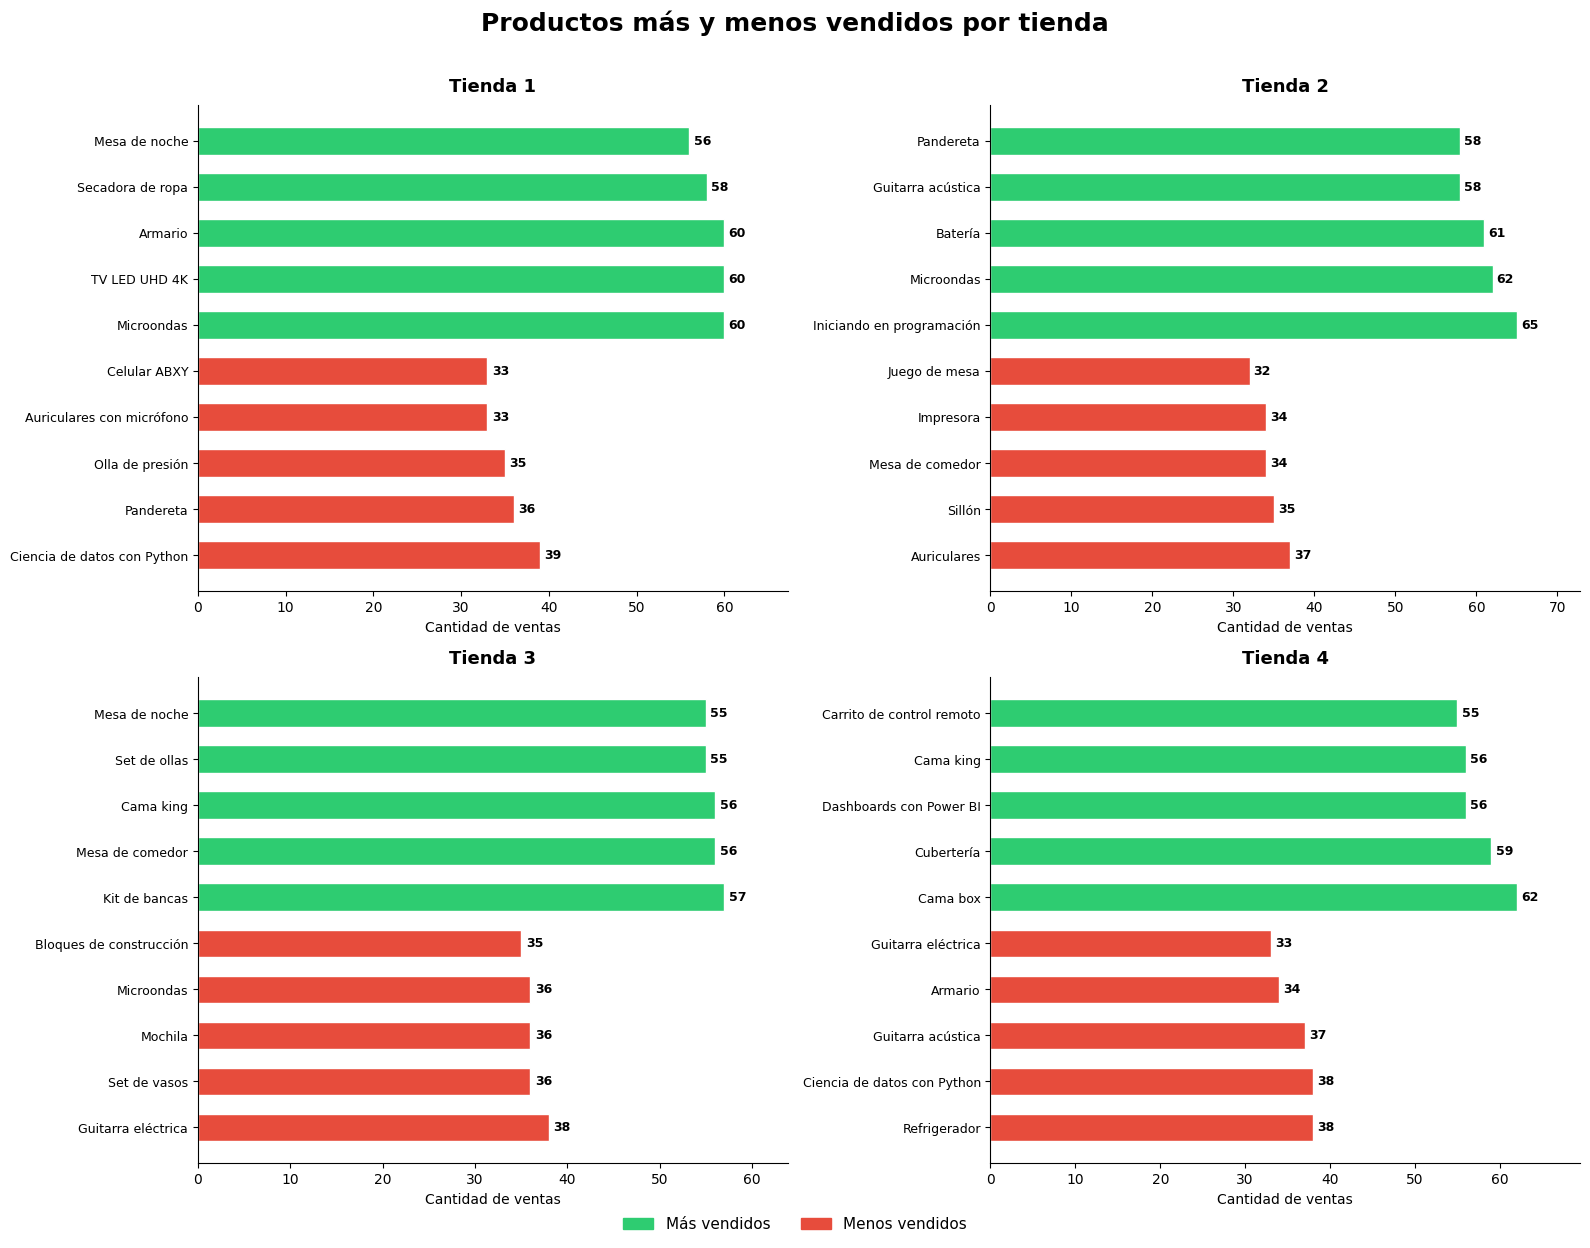

In [28]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Productos más y menos vendidos por tienda", fontsize=18, fontweight="bold", y=1.01)

COLOR_TOP = "#2ecc71"
COLOR_BOT = "#e74c3c"

for ax, (nombre, df) in zip(axes.flatten(), tiendas.items()):
    vc = df["Producto"].value_counts()
    top5 = vc.head(5)
    bot5 = vc.tail(5)

    productos = list(bot5.index) + list(top5.index)
    ventas    = list(bot5.values) + list(top5.values)
    colores   = [COLOR_BOT] * 5 + [COLOR_TOP] * 5

    bars = ax.barh(productos, ventas, color=colores, edgecolor="white", height=0.6)

    for bar, val in zip(bars, ventas):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9, fontweight="bold")

    ax.set_title(nombre, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Cantidad de ventas", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)
    ax.set_xlim(0, max(ventas) * 1.12)

patch_top = mpatches.Patch(color=COLOR_TOP, label="Más vendidos")
patch_bot = mpatches.Patch(color=COLOR_BOT, label="Menos vendidos")
fig.legend(handles=[patch_top, patch_bot], loc="lower center",
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("productos_mas_menos_vendidos.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Envío promedio por tienda

In [26]:
tienda  = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tiendas = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

print("Costo de envío promedio por tienda (pagado por el cliente):")
for nombre, df in tiendas.items():
    promedio = df["Costo de envío"].mean()
    print(f"  {nombre}: {promedio:.2f}")

Costo de envío promedio por tienda (pagado por el cliente):
  Tienda 1: 26018.61
  Tienda 2: 25216.24
  Tienda 3: 24805.68
  Tienda 4: 23459.46


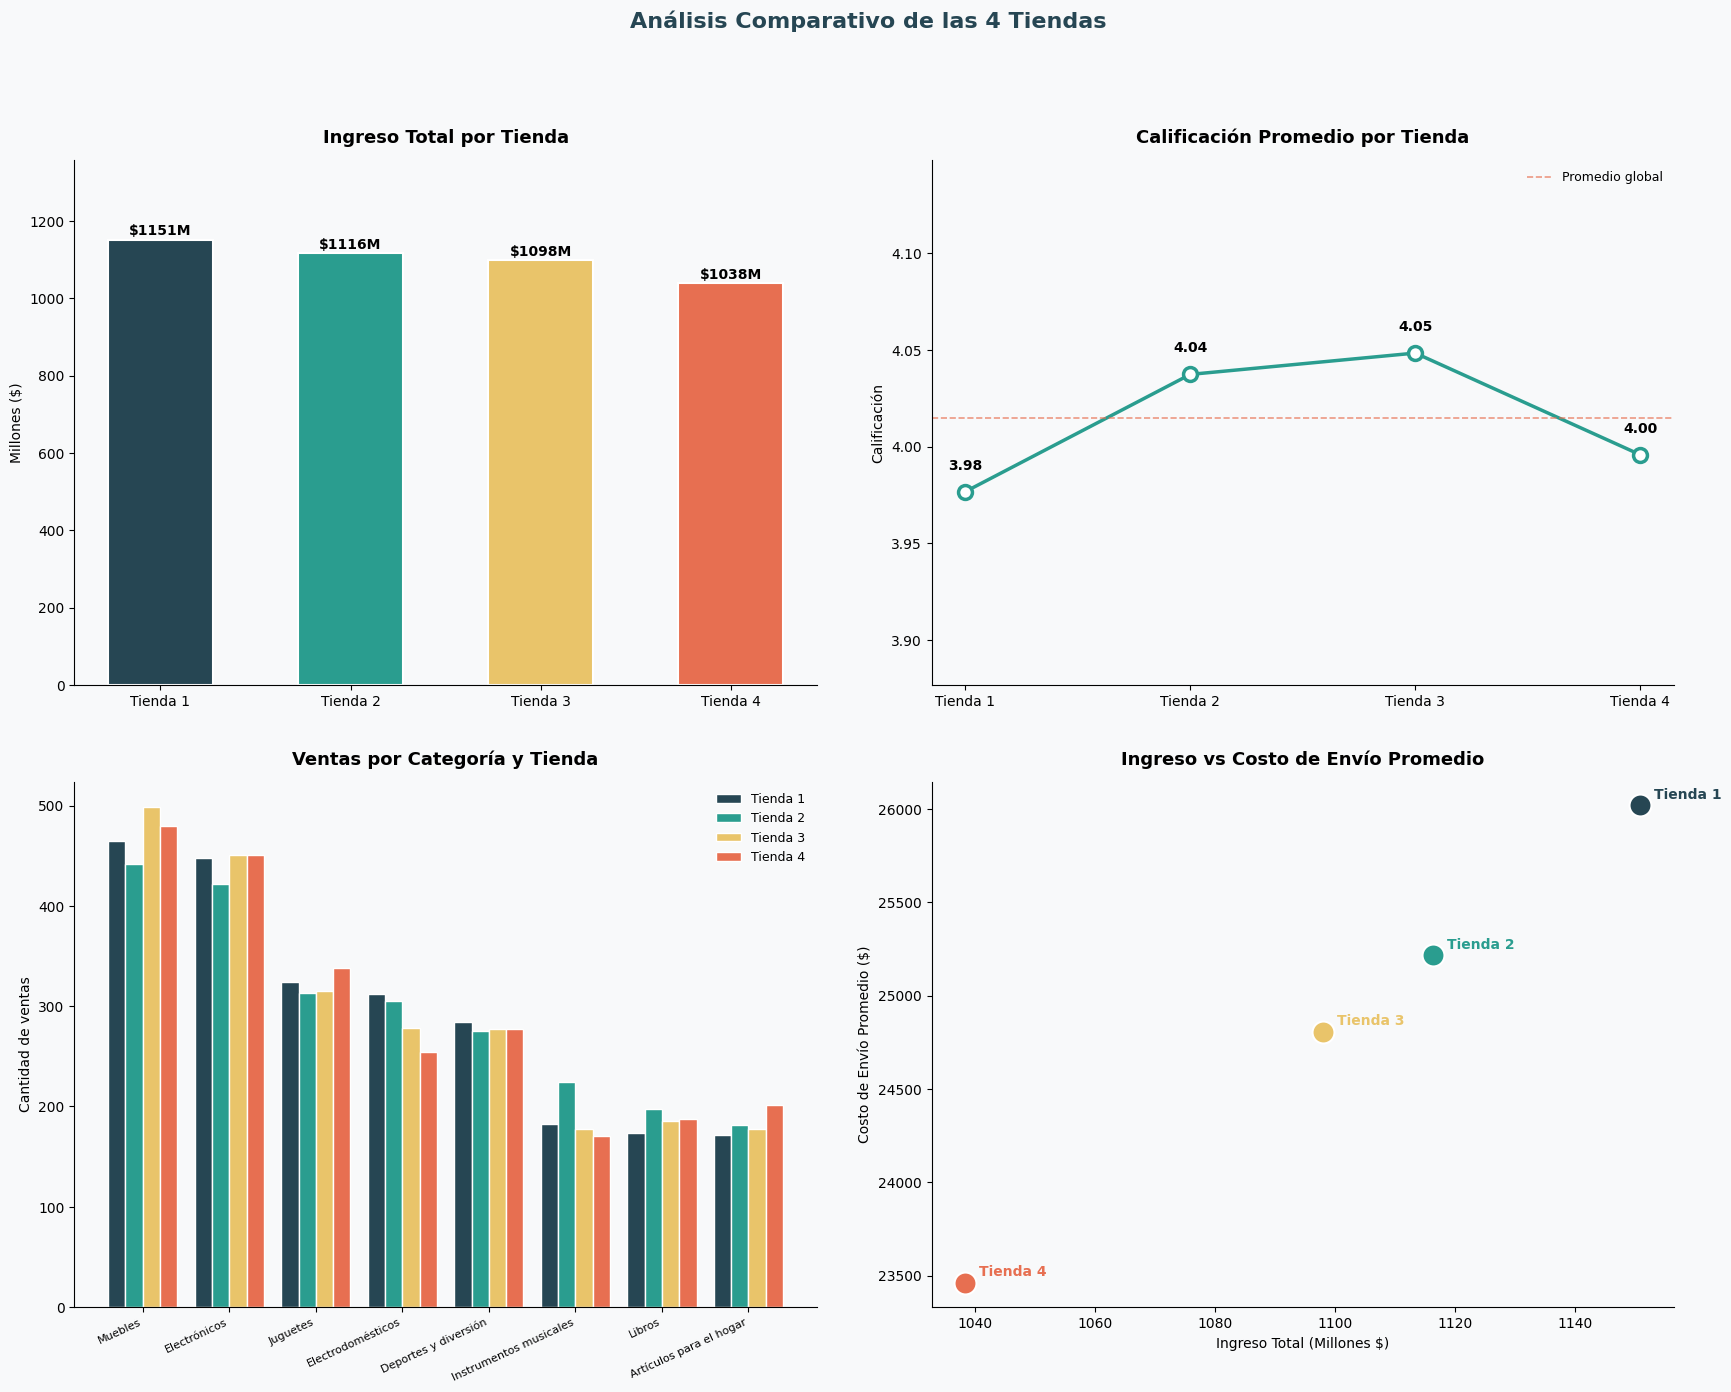

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
dfs = {
    "Tienda 1": tienda,
    "Tienda 2": tienda2,
    "Tienda 3": tienda3,
    "Tienda 4": tienda4,
}

nombres        = list(dfs.keys())
ingresos       = [df["Precio"].sum() / 1e6 for df in dfs.values()]
calificaciones = [df["Calificación"].mean() for df in dfs.values()]
envios         = [df["Costo de envío"].mean() for df in dfs.values()]

PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#f8f9fa")

# ── Gráfico 1: Ingresos totales (barras) ──────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor("#f8f9fa")
bars = ax1.bar(nombres, ingresos, color=PALETTE, edgecolor="white", linewidth=1.5, width=0.55)
for bar, val in zip(bars, ingresos):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f"${val:.0f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Ingreso Total por Tienda", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Millones ($)", fontsize=10)
ax1.set_ylim(0, max(ingresos) * 1.18)
ax1.spines[["top", "right"]].set_visible(False)

# ── Gráfico 2: Calificación promedio (línea con puntos) ───────────────────────
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor("#f8f9fa")
ax2.plot(nombres, calificaciones, marker="o", markersize=10, linewidth=2.5,
         color="#2a9d8f", markerfacecolor="white", markeredgewidth=2.5)
for x, y in zip(nombres, calificaciones):
    ax2.text(x, y + 0.01, f"{y:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_title("Calificación Promedio por Tienda", fontsize=13, fontweight="bold", pad=12)
ax2.set_ylabel("Calificación", fontsize=10)
ax2.set_ylim(min(calificaciones) - 0.1, max(calificaciones) + 0.1)
ax2.spines[["top", "right"]].set_visible(False)
ax2.axhline(y=sum(calificaciones) / len(calificaciones), color="#e76f51",
            linestyle="--", linewidth=1.2, alpha=0.7, label="Promedio global")
ax2.legend(fontsize=9, frameon=False)

# ── Gráfico 3: Distribución de categorías (barras agrupadas) ──────────────────
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor("#f8f9fa")
categorias = list(tienda["Categoría del Producto"].value_counts().index)
x = np.arange(len(categorias))
width = 0.2
for i, (nombre, df) in enumerate(dfs.items()):
    vc = df["Categoría del Producto"].value_counts()
    vals = [vc.get(c, 0) for c in categorias]
    ax3.bar(x + i * width, vals, width, label=nombre, color=PALETTE[i], edgecolor="white")
ax3.set_title("Ventas por Categoría y Tienda", fontsize=13, fontweight="bold", pad=12)
ax3.set_ylabel("Cantidad de ventas", fontsize=10)
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels(categorias, rotation=25, ha="right", fontsize=8)
ax3.legend(fontsize=9, frameon=False)
ax3.spines[["top", "right"]].set_visible(False)

# ── Gráfico 4: Ingreso vs Costo de envío (dispersión) ─────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor("#f8f9fa")
for nombre, color, ing, env in zip(nombres, PALETTE, ingresos, envios):
    ax4.scatter(ing, env, s=250, color=color, zorder=5, edgecolors="white", linewidth=1.5)
    ax4.annotate(nombre, (ing, env), textcoords="offset points",
                 xytext=(10, 5), fontsize=10, fontweight="bold", color=color)
ax4.set_title("Ingreso vs Costo de Envío Promedio", fontsize=13, fontweight="bold", pad=12)
ax4.set_xlabel("Ingreso Total (Millones $)", fontsize=10)
ax4.set_ylabel("Costo de Envío Promedio ($)", fontsize=10)
ax4.spines[["top", "right"]].set_visible(False)

plt.suptitle("Análisis Comparativo de las 4 Tiendas", fontsize=16,
             fontweight="bold", y=1.01, color="#264653")
plt.tight_layout(pad=3.0)
plt.savefig("analisis_visualizaciones.png", dpi=150, bbox_inches="tight", facecolor="#f8f9fa")
plt.show()


# Informe Final — Análisis de las 4 Tiendas del Sr. Juan

## 1. Introducción

El presente informe tiene como objetivo analizar el desempeño de las cuatro tiendas del Sr. Juan, con el fin de identificar cuál de ellas presenta el rendimiento más bajo y, por lo tanto, debería considerarse para la venta. Para ello se evaluaron cinco dimensiones clave: ingresos totales, ventas por categoría de producto, calificaciones promedio de clientes, productos más y menos vendidos, y costo de envío promedio. Los datos analizados provienen de los registros de facturación de cada tienda.

---

## 2. Desarrollo del Análisis

### 2.1 Ingresos Totales

| Tienda   | Ingreso Total       | Posición |
|----------|---------------------|----------|
| Tienda 1 | $1.150.880.400      | 🥇 1°    |
| Tienda 2 | $1.116.343.500      | 2°       |
| Tienda 3 | $1.098.019.600      | 3°       |
| Tienda 4 | $1.038.375.700      | 🔴 4°    |

**Tienda 1** lidera en facturación con $1.150 millones, mientras que **Tienda 4** es la de menor ingreso total, con una diferencia de aproximadamente $112 millones respecto a la primera. Esta brecha representa casi un 10% menos de ingresos que la tienda líder.

---

### 2.2 Categorías de Productos más y menos Vendidas

En todas las tiendas, **Muebles** y **Electrónicos** son consistentemente las categorías más vendidas, lo que indica que el mercado tiene una demanda consolidada en estos rubros.

| Tienda   | Categoría más vendida  | Unidades | Categoría menos vendida     | Unidades |
|----------|------------------------|----------|-----------------------------|----------|
| Tienda 1 | Muebles                | 465      | Artículos para el hogar     | 171      |
| Tienda 2 | Muebles                | 442      | Artículos para el hogar     | 181      |
| Tienda 3 | Muebles                | 499      | Artículos para el hogar     | 177      |
| Tienda 4 | Muebles                | 480      | Instrumentos musicales      | 170      |

La distribución de categorías es relativamente homogénea entre tiendas. Sin embargo, **Tienda 4** es la única que tiene a *Instrumentos musicales* como categoría menos vendida (170 unidades), mientras las demás tienen a *Artículos para el hogar*. Esto sugiere que Tienda 4 tiene un mix de productos con menor demanda en ese segmento.

---

### 2.3 Calificaciones Promedio de Clientes

| Tienda   | Calificación Promedio | Posición |
|----------|-----------------------|----------|
| Tienda 3 | 4.05                  | 🥇 1°    |
| Tienda 2 | 4.04                  | 2°       |
| Tienda 4 | 4.00                  | 3°       |
| Tienda 1 | 3.98                  | 🔴 4°    |

**Tienda 1** presenta la calificación más baja (3.98), lo que indica menor satisfacción del cliente en comparación con las demás. **Tienda 3** y **Tienda 2** lideran en este indicador, con calificaciones por encima del promedio global (4.02).

---

### 2.4 Productos más y menos Vendidos

| Tienda   | Producto más vendido          | Ventas | Producto menos vendido    | Ventas |
|----------|-------------------------------|--------|---------------------------|--------|
| Tienda 1 | Microondas                    | 60     | Celular ABXY              | 33     |
| Tienda 2 | Iniciando en programación     | 65     | Juego de mesa             | 32     |
| Tienda 3 | Kit de bancas                 | 57     | Bloques de construcción   | 35     |
| Tienda 4 | Cama box                      | 62     | Guitarra eléctrica        | 33     |

Los productos menos vendidos son similares en volumen entre tiendas (32–35 unidades). La diferencia más notoria está en los productos estrella: **Tienda 2** destaca con 65 ventas de su producto top, mientras que **Tienda 3** es la de menor pico (57 unidades).

---

### 2.5 Costo de Envío Promedio

| Tienda   | Costo Promedio de Envío | Posición        |
|----------|-------------------------|-----------------|
| Tienda 1 | $26.019                 | 🔴 Más alto     |
| Tienda 2 | $25.216                 | 2°              |
| Tienda 3 | $24.806                 | 3°              |
| Tienda 4 | $23.459                 | 🥇 Más bajo     |

**Tienda 4** ofrece el menor costo de envío promedio para el cliente ($23.459), lo que podría considerarse una ventaja competitiva. **Tienda 1** cobra el envío más caro ($26.019), lo que puede impactar negativamente en la experiencia de compra.

---

## 3. Resumen Comparativo

| Indicador                | Tienda 1 | Tienda 2 | Tienda 3 | Tienda 4 |
|--------------------------|----------|----------|----------|----------|
| Ingreso total            | 🥇 1°    | 2°       | 3°       | 🔴 4°    |
| Calificación promedio    | 🔴 4°    | 2°       | 🥇 1°    | 3°       |
| Costo de envío promedio  | 🔴 Alto  | Medio    | Medio    | 🥇 Bajo  |
| Categoría top            | Muebles  | Muebles  | Muebles  | Muebles  |
| Producto más vendido     | 60 uds.  | 65 uds.  | 57 uds.  | 62 uds.  |

---

## 4. Conclusión y Recomendación

Luego de evaluar los cinco indicadores analizados, la recomendación es que el **Sr. Juan venda la Tienda 4**.

Las razones que respaldan esta decisión son:

1. **Es la tienda con menores ingresos totales.** Con $1.038 millones, está $112 millones por debajo de Tienda 1, la líder. Es la única que no supera los $1.100 millones.

2. **Su mix de categorías tiene una debilidad particular.** Es la única tienda donde *Instrumentos musicales* es la categoría menos vendida (en lugar de *Artículos para el hogar* como en las demás), lo que indica que su catálogo tiene segmentos de bajo rendimiento que no se repiten en las otras tiendas.

3. **Su calificación promedio (4.00) es la tercera más baja**, por debajo de Tienda 2 (4.04) y Tienda 3 (4.05), lo que refleja una satisfacción del cliente moderada.

4. **El único punto positivo de Tienda 4 es su costo de envío promedio más bajo** ($23.459), pero este beneficio para el cliente no se traduce en mayores ingresos ni en mejor satisfacción, lo que sugiere que no está siendo aprovechado como ventaja competitiva real.

En contraposición, **Tienda 1** es la más rentable en términos de ingresos y sería la menos indicada para vender, a pesar de tener la calificación más baja, ya que su volumen de facturación la posiciona como el activo más valioso del portafolio.

> **Decisión final: vender Tienda 4**, ya que combina los menores ingresos del grupo con una satisfacción de cliente intermedia y un mix de productos con segmentos débiles, lo que la convierte en la opción menos estratégica dentro del portafolio del Sr. Juan.